In [42]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as sm
from pandas.tseries.offsets import *

In [49]:
pred_path = "final_results.csv"
pred = pd.read_csv(pred_path, parse_dates=["date"])
pred = pred[pred['returns'] != 0]
pred.tail(10)

,Unnamed: 0,date,returns
116,116,2024-09-01,0.106298
117,117,2024-10-01,0.146554
118,118,2024-11-01,0.093423
119,119,2024-12-01,-0.022408
120,120,2025-01-01,-0.014105
121,121,2025-02-01,0.034675
122,122,2025-03-01,0.018731
123,123,2025-04-01,0.001206
124,124,2025-05-01,-0.012591
125,125,2025-06-01,0.064571


In [45]:
pairs_count_path = "pairs-trade-counts-per-month.csv"
pairs_trades_count = pd.read_csv(pairs_count_path)
pairs_trades_count# Convert to datetime (defaults to first day of the month)
pairs_trades_count['date'] = pd.to_datetime(pairs_trades_count['year_month'], format='%Y-%m')

# Extract year and month
pairs_trades_count['year'] = pairs_trades_count['date'].dt.year
pairs_trades_count['month'] = pairs_trades_count['date'].dt.month
pairs_trades_count.drop(['Unnamed: 0', 'date'], axis=1, inplace=True)
pairs_trades_count.tail(10)

,year_month,count,year,month
116,2024-09,1,2024,9
117,2024-10,6,2024,10
118,2024-11,8,2024,11
119,2024-12,21,2024,12
120,2025-01,0,2025,1
121,2025-02,10,2025,2
122,2025-03,12,2025,3
123,2025-04,5,2025,4
124,2025-05,9,2025,5
125,2025-06,20,2025,6


In [70]:
import pandas as pd

# --- Step 1: Read CSV ---
pairs_path = "pair-trade-per-month.csv"
pairs_trades = pd.read_csv(pairs_path)

# --- Step 2: Convert exit_date to datetime ---
pairs_trades['date'] = pd.to_datetime(pairs_trades['exit_date'], format='%Y%m%d')

# --- Step 3: Extract year and month ---
pairs_trades['year'] = pairs_trades['date'].dt.year
pairs_trades['month'] = pairs_trades['date'].dt.month

# --- Step 4: Compute returns_pairs ---
pairs_trades['returns_pairs'] = pairs_trades['avg_pnl_dollars'] - 1

# Drop unused columns
pairs_trades.drop(['Unnamed: 0', 'exit_date', 'log', 'sum', 'bench', 'avg_pnl_dollars'], axis=1, inplace=True)

# --- Step 5: Aggregate returns per month ---
monthly_pairs = pairs_trades.groupby(['year','month'], as_index=False).agg({'returns_pairs':'sum'})

# --- Step 6: Create full month range ---
full_months = pd.date_range(start='2015-01-01', end='2025-07', freq='M')
full_df = pd.DataFrame({'date': full_months})
full_df['year'] = full_df['date'].dt.year
full_df['month'] = full_df['date'].dt.month

# --- Step 7: Merge aggregated returns with full months ---
monthly_pairs = full_df.merge(monthly_pairs, on=['year','month'], how='left')

# Fill missing months with 0 returns
monthly_pairs['returns_pairs'] = monthly_pairs['returns_pairs'].fillna(0)

# Keep only necessary columns
monthly_pairs = monthly_pairs[['date','year','month','returns_pairs']]

# --- Result ---
monthly_pairs


,date,year,month,returns_pairs
0,2015-01-31,2015,1,0.000000
1,2015-02-28,2015,2,0.022418
2,2015-03-31,2015,3,0.007606
3,2015-04-30,2015,4,0.046160
4,2015-05-31,2015,5,0.028534
...,...,...,...,...
121,2025-02-28,2025,2,0.034950
122,2025-03-31,2025,3,-0.010664
123,2025-04-30,2025,4,-0.011701
124,2025-05-31,2025,5,-0.061096


In [71]:
snp_returns_path = "mkt_ind.csv"
snp_returns = pd.read_csv(snp_returns_path)
snp_returns = snp_returns[snp_returns["year"] >= 2015]
snp_returns

,rf,year,month,ret
120,0.0000,2015,1,-0.031041
121,0.0000,2015,2,0.054893
122,0.0000,2015,3,-0.017396
123,0.0000,2015,4,0.008521
124,0.0000,2015,5,0.010491
...,...,...,...,...
241,0.0033,2025,2,-0.014242
242,0.0034,2025,3,-0.057545
243,0.0035,2025,4,-0.007625
244,0.0038,2025,5,0.061524


In [76]:
monthly_portfolio = pred.copy()
monthly_portfolio['date'] = pd.to_datetime(pred['date'])

# Extract year and month
monthly_portfolio['year'] = monthly_portfolio['date'].dt.year.copy()
monthly_portfolio['month'] = monthly_portfolio['date'].dt.month.copy()
monthly_portfolio.drop

monthly_portfolio.drop('Unnamed: 0', axis=1, inplace=True)
monthly_portfolio = monthly_portfolio.merge(pairs_trades_count, how="inner", on=["year", "month"])
monthly_portfolio['returns'] = (monthly_portfolio['returns']*200 + monthly_pairs['returns_pairs']*pairs_trades_count["count"])/(200+pairs_trades_count["count"])
monthly_portfolio.tail(10)
len(monthly_portfolio)
len(pairs_trades_count)

monthly_portfolio


,date,returns,year,month,year_month,count
0,2015-01-01,0.028056,2015,1,2015-01,0
1,2015-02-01,0.067645,2015,2,2015-02,9
2,2015-03-01,-0.007518,2015,3,2015-03,10
3,2015-04-01,-0.021545,2015,4,2015-04,13
4,2015-05-01,0.027003,2015,5,2015-05,6
...,...,...,...,...,...,...
121,2025-02-01,0.034688,2025,2,2025-02,10
122,2025-03-01,0.017067,2025,3,2025-03,12
123,2025-04-01,0.000891,2025,4,2025-04,5
124,2025-05-01,-0.014679,2025,5,2025-05,9


### Sharpe Ratio

In [77]:
sharpe = (
    monthly_portfolio["returns"].mean() / monthly_portfolio["returns"].std() * np.sqrt(12)
)  # Sharpe ratio is annualized
print("Sharpe Ratio:", sharpe)
ann_std = monthly_portfolio["returns"].std() * np.sqrt(12)
print("Annualized Standard Deviation:", ann_std)

Sharpe Ratio: 0.923443749695208
Annualized Standard Deviation: 0.20257605253915056


In [78]:
monthly_portfolio_merged = monthly_portfolio.merge(snp_returns, how="inner", on=["year", "month"])
monthly_portfolio_merged

,date,returns,year,month,year_month,count,rf,ret
0,2015-01-01,0.028056,2015,1,2015-01,0,0.0000,-0.031041
1,2015-02-01,0.067645,2015,2,2015-02,9,0.0000,0.054893
2,2015-03-01,-0.007518,2015,3,2015-03,10,0.0000,-0.017396
3,2015-04-01,-0.021545,2015,4,2015-04,13,0.0000,0.008521
4,2015-05-01,0.027003,2015,5,2015-05,6,0.0000,0.010491
...,...,...,...,...,...,...,...,...
121,2025-02-01,0.034688,2025,2,2025-02,10,0.0033,-0.014242
122,2025-03-01,0.017067,2025,3,2025-03,12,0.0034,-0.057545
123,2025-04-01,0.000891,2025,4,2025-04,5,0.0035,-0.007625
124,2025-05-01,-0.014679,2025,5,2025-05,9,0.0038,0.061524


### Annualized Alpha

In [79]:
monthly_portfolio_merged = monthly_portfolio.merge(snp_returns, how="inner", on=["year", "month"])
# Newy-West regression for heteroskedasticity and autocorrelation robust standard errors
nw_ols = sm.ols(formula="returns ~ rf", data=monthly_portfolio_merged).fit(
    cov_type="HAC", cov_kwds={"maxlags": 3}, use_t=True
)
print(nw_ols.summary())

# Specifically, the alpha, t-statistic, and Information ratio are:
print("CAPM Alpha:", nw_ols.params["Intercept"]*12)
print("t-statistic:", nw_ols.tvalues["Intercept"])

                            OLS Regression Results                            
Dep. Variable:                returns   R-squared:                       0.049
Model:                            OLS   Adj. R-squared:                  0.041
Method:                 Least Squares   F-statistic:                     4.091
Date:                Sat, 04 Oct 2025   Prob (F-statistic):             0.0453
Time:                        23:23:57   Log-Likelihood:                 182.61
No. Observations:                 126   AIC:                            -361.2
Df Residuals:                     124   BIC:                            -355.5
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0035      0.006      0.603      0.5

### Information Ratio

In [80]:
print(
    "Information Ratio:",
    nw_ols.params["Intercept"] / np.sqrt(nw_ols.mse_resid) * np.sqrt(12),
)  # Information ratio is annualized

Information Ratio: 0.21062240373457464


### Max One-Month Loss

In [81]:
max_1m_loss = monthly_portfolio["returns"].min()
print("Max 1-Month Loss:", max_1m_loss)

Max 1-Month Loss: -0.16451149


### Max Drawdown

In [83]:
# Calculate Drawdown of the long-short Portfolio
# you can use the same formula to calculate the Sharpe ratio for the long and short portfolios separately
monthly_portfolio["log_returns"] = np.log(
    monthly_portfolio["returns"] + 1
)  # calculate log returns
monthly_portfolio["cumsum_log_returns"] = monthly_portfolio["log_returns"].cumsum(
    axis=0
)  # calculate cumulative log returns
rolling_peak = monthly_portfolio["cumsum_log_returns"].cummax()
drawdowns = rolling_peak - monthly_portfolio["cumsum_log_returns"]
max_drawdown = drawdowns.max()
print("Maximum Drawdown:", max_drawdown)

Maximum Drawdown: 0.48724262094319665


### Turnover

In [84]:
# Calculate Turnover of the long portfolio and short portfolio
def turnover_count(df):
    # count the number of stocks at the begnning of each month
    start_stocks = df[["id", "date"]].copy()
    start_stocks = start_stocks.sort_values(by=["date", "id"])
    start_count = start_stocks.groupby(["date"])["id"].count().reset_index()

    end_stocks = df[["id", "date"]].copy()
    end_stocks["date"] = end_stocks["date"] - MonthBegin(
        1
    )  # shift the date to the beginning of the next month
    end_stocks = end_stocks.sort_values(by=["date", "id"])

    remain_stocks = start_stocks.merge(end_stocks, on=["date", "id"], how="inner")
    remain_count = (
        remain_stocks.groupby(["date"])["id"].count().reset_index()
    )  # count the number of stocks that remain in the next month
    remain_count = remain_count.rename(columns={"id": "remain_count"})

    port_count = start_count.merge(remain_count, on=["date"], how="inner")
    port_count["turnover"] = (
        port_count["id"] - port_count["remain_count"]
    ) / port_count[
        "id"
    ]  # calculate the turnover as the average of the percentage of stocks that are replaced each month
    return port_count["turnover"].mean()

long_positions = pred[pred["rank"] == 9]
short_positions = pred[pred["rank"] == 0]
print("Long Portfolio Turnover:", turnover_count(long_positions))
print("Short Portfolio Turnover:", turnover_count(short_positions))

KeyError: 'rank'

In [85]:
monthly_portfolio

,date,returns,year,month,year_month,count,log_returns,cumsum_log_returns
0,2015-01-01,0.028056,2015,1,2015-01,0,0.027670,0.027670
1,2015-02-01,0.067645,2015,2,2015-02,9,0.065455,0.093125
2,2015-03-01,-0.007518,2015,3,2015-03,10,-0.007546,0.085578
3,2015-04-01,-0.021545,2015,4,2015-04,13,-0.021780,0.063798
4,2015-05-01,0.027003,2015,5,2015-05,6,0.026645,0.090443
...,...,...,...,...,...,...,...,...
121,2025-02-01,0.034688,2025,2,2025-02,10,0.034100,1.676741
122,2025-03-01,0.017067,2025,3,2025-03,12,0.016923,1.693664
123,2025-04-01,0.000891,2025,4,2025-04,5,0.000891,1.694555
124,2025-05-01,-0.014679,2025,5,2025-05,9,-0.014788,1.679767


In [86]:
monthly_portfolio["cumulative returns"] = np.exp(monthly_portfolio["cumsum_log_returns"]) - 1
monthly_portfolio.tail()

,date,returns,year,month,year_month,count,log_returns,cumsum_log_returns,cumulative returns
121,2025-02-01,0.034688,2025,2,2025-02,10,0.034100,1.676741,4.348097
122,2025-03-01,0.017067,2025,3,2025-03,12,0.016923,1.693664,4.439374
123,2025-04-01,0.000891,2025,4,2025-04,5,0.000891,1.694555,4.444222
124,2025-05-01,-0.014679,2025,5,2025-05,9,-0.014788,1.679767,4.364304
125,2025-06-01,0.064634,2025,6,2025-06,20,0.062631,1.742398,4.711022


In [87]:
snp_returns["log_returns"] = np.log(
    snp_returns["ret"] + 1
)  # calculate log returns
snp_returns["cumsum_log_returns"] = snp_returns["log_returns"].cumsum(
    axis=0
)
snp_returns["exp"] = np.exp(snp_returns["cumsum_log_returns"]) - 1
snp_returns

,rf,year,month,ret,log_returns,cumsum_log_returns,exp
120,0.0000,2015,1,-0.031041,-0.031533,-0.031533,-0.031041
121,0.0000,2015,2,0.054893,0.053439,0.021906,0.022148
122,0.0000,2015,3,-0.017396,-0.017549,0.004357,0.004366
123,0.0000,2015,4,0.008521,0.008485,0.012842,0.012924
124,0.0000,2015,5,0.010491,0.010437,0.023278,0.023551
...,...,...,...,...,...,...,...
241,0.0033,2025,2,-0.014242,-0.014345,1.061975,1.892078
242,0.0034,2025,3,-0.057545,-0.059267,1.002709,1.725654
243,0.0035,2025,4,-0.007625,-0.007654,0.995054,1.704872
244,0.0038,2025,5,0.061524,0.059705,1.054760,1.871286


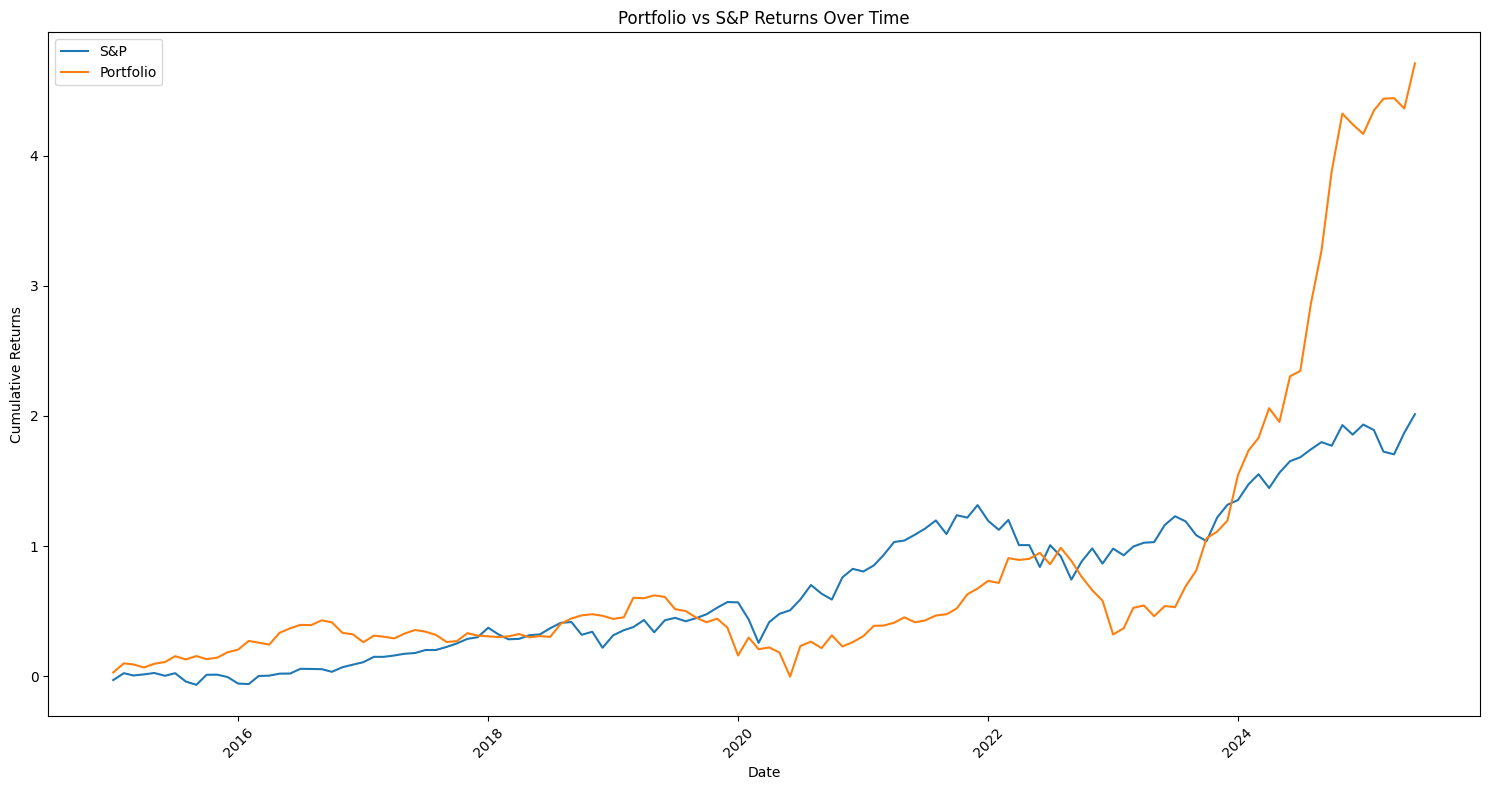

In [88]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert year and month into a datetime column
monthly_portfolio['date'] = pd.to_datetime(monthly_portfolio[['year', 'month']].assign(day=1))
snp_returns['date'] = pd.to_datetime(snp_returns[['year', 'month']].assign(day=1))  # if S&P has year/month too

# Plot
fig = plt.figure(figsize=(15, 8))
plt.plot(snp_returns["date"], snp_returns["exp"], label="S&P")
plt.plot(monthly_portfolio["date"], monthly_portfolio["cumulative returns"], label="Portfolio")

plt.xlabel("Date")
plt.ylabel("Cumulative Returns")
plt.title("Portfolio vs S&P Returns Over Time")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [39]:
monthly_portfolio

,date,returns,year,month,log_returns,cumsum_log_returns,cumulative returns
0,2015-01-01,0.028056,2015,1,0.027670,0.027670,0.028056
1,2015-02-01,0.067007,2015,2,0.064857,0.092527,0.096943
2,2015-03-01,-0.005682,2015,3,-0.005698,0.086829,0.090710
3,2015-04-01,-0.022620,2015,4,-0.022880,0.063949,0.066038
4,2015-05-01,0.026713,2015,5,0.026362,0.090311,0.094515
...,...,...,...,...,...,...,...
127,2025-08-01,NaN,2025,8,NaN,NaN,NaN
128,2025-09-01,NaN,2025,9,NaN,NaN,NaN
129,2025-10-01,NaN,2025,10,NaN,NaN,NaN
130,2025-11-01,NaN,2025,11,NaN,NaN,NaN


In [40]:
monthly_portfolio['date'] = pd.to_datetime(monthly_portfolio[['year', 'month']].assign(day=1))
monthly_portfolio

,date,returns,year,month,log_returns,cumsum_log_returns,cumulative returns
0,2015-01-01,0.028056,2015,1,0.027670,0.027670,0.028056
1,2015-02-01,0.067007,2015,2,0.064857,0.092527,0.096943
2,2015-03-01,-0.005682,2015,3,-0.005698,0.086829,0.090710
3,2015-04-01,-0.022620,2015,4,-0.022880,0.063949,0.066038
4,2015-05-01,0.026713,2015,5,0.026362,0.090311,0.094515
...,...,...,...,...,...,...,...
127,2025-08-01,NaN,2025,8,NaN,NaN,NaN
128,2025-09-01,NaN,2025,9,NaN,NaN,NaN
129,2025-10-01,NaN,2025,10,NaN,NaN,NaN
130,2025-11-01,NaN,2025,11,NaN,NaN,NaN
